In [22]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shaza\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\shaza\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\shaza\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [11]:
import pandas as pd

df = pd.read_csv(r"D:\Amazon dataset\train.ft.txt.bz2", 
                 header=None, 
                 names=["text"], 
                 nrows=50000,
                 sep="\t",
                 on_bad_lines="skip")
df.head(10)

,text
0,__label__2 Stuning even for the non-gamer: Thi...
1,__label__2 The best soundtrack ever to anythin...
2,__label__2 Amazing!: This soundtrack is my fav...
3,__label__2 Excellent Soundtrack: I truly like ...
4,"__label__2 Remember, Pull Your Jaw Off The Flo..."
5,__label__2 an absolute masterpiece: I am quite...
6,__label__1 Buyer beware: This is a self-publis...
7,__label__2 Glorious story: I loved Whisper of ...
8,__label__2 A FIVE STAR BOOK: I just finished r...
9,__label__2 Whispers of the Wicked Saints: This...


In [17]:
print(df.columns.tolist())
print(df.head())

['review', 'sentiment']
                                              review  sentiment
0  Stuning even for the non-gamer: This sound tra...          1
1  The best soundtrack ever to anything.: I'm rea...          1
2  Amazing!: This soundtrack is my favorite music...          1
3  Excellent Soundtrack: I truly like this soundt...          1
4  Remember, Pull Your Jaw Off The Floor After He...          1


In [18]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['cleaned'] = df['review'].apply(clean_text)
df[['review', 'cleaned']].head()

,review,cleaned
0,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hand in...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Convert text to numbers
tfidf = TfidfVectorizer(max_features=10000)
X = tfidf.fit_transform(df['cleaned'])
y = df['sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8778
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      4955
           1       0.87      0.89      0.88      5045

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



Matplotlib is building the font cache; this may take a moment.


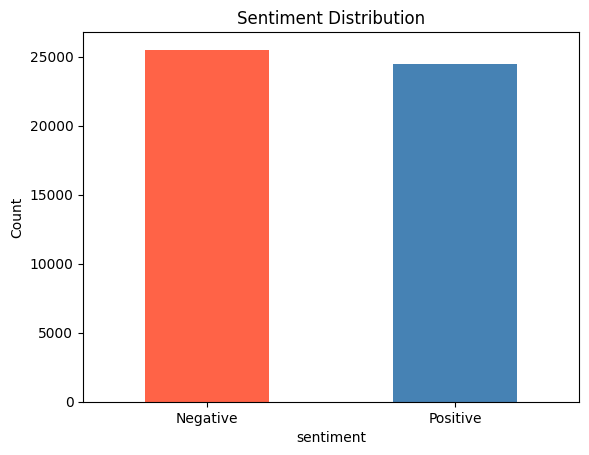

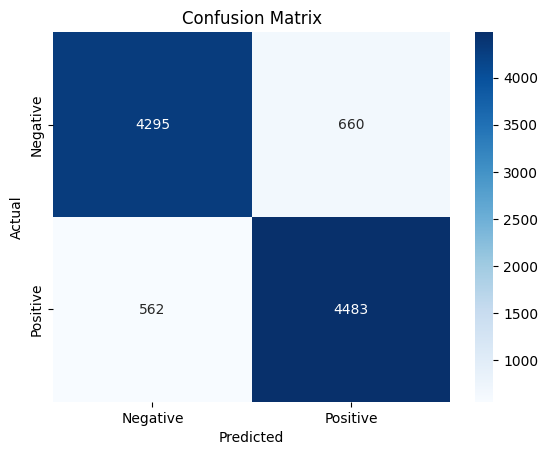

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Chart 1 - Sentiment Distribution
df['sentiment'].value_counts().plot(kind='bar', color=['tomato', 'steelblue'])
plt.title('Sentiment Distribution')
plt.xticks([0, 1], ['Negative', 'Positive'], rotation=0)
plt.ylabel('Count')
plt.show()

# Chart 2 - Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [24]:
import pickle

# Save the model
pickle.dump(model, open('sentiment_model.pkl', 'wb'))
pickle.dump(tfidf, open('tfidf.pkl', 'wb'))

print("Model saved successfully!")

Model saved successfully!


In [25]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    confidence = model.predict_proba(vectorized)[0]
    
    label = "Positive 😊" if prediction == 1 else "Negative 😞"
    score = round(max(confidence) * 100, 2)
    
    print(f"Review: {text}")
    print(f"Sentiment: {label}")
    print(f"Confidence: {score}%")
    print("-" * 40)

# Test it out
predict_sentiment("This product is absolutely amazing, I love it!")
predict_sentiment("Worst purchase I have ever made, total waste of money")
predict_sentiment("It was okay, nothing special")

Review: This product is absolutely amazing, I love it!
Sentiment: Positive 😊
Confidence: 99.65%
----------------------------------------
Review: Worst purchase I have ever made, total waste of money
Sentiment: Negative 😞
Confidence: 99.99%
----------------------------------------
Review: It was okay, nothing special
Sentiment: Negative 😞
Confidence: 97.54%
----------------------------------------
